# 1. Simulation

In [ ]:
import numpy as np
import pandas as pd
import gymnasium as gym
import cam_env_5050_entry
import cam_env_cat_entry

MOUSE_STATES = {
        (1,3):0,
        (1,4):1, (1,5):1,
        (2,3):2,
        (2,4):3, (2,5):3,
        (3,3):4,
        (3,4):5, (3,5):5
    }

CAT_STATES = {
        (1,3):0, (2,3):0,
        (1,4):1, (2,4):1, 
        (1,5):2, (2,5):2, 
        (3,3):3,
        (3,4):4, 
        (3,5):5
    }

def get_cat_state_num(observation):
    return CAT_STATES.get(observation)

def get_mouse_state_num(observation):
    return MOUSE_STATES.get(observation)


## 1.1 Simulation (Cat Entry)

In [5]:
q_cat = pd.read_csv("iql_cat_entry_cat.csv")
q_cat = q_cat.drop(q_cat.columns[[0]], axis=1).to_numpy()

q_mouse = pd.read_csv("iql_cat_entry_mouse.csv")
q_mouse = q_mouse.drop(q_mouse.columns[[0]], axis=1).to_numpy()

env = gym.make("CatAndMouse-cat_entry", render_mode = "human")

terminated = False
truncated = False

observation, info = env.reset()

while(not terminated and not truncated):
    cat_state_num = get_cat_state_num(observation)
    mouse_state_num = get_mouse_state_num(observation)
    
    cat_action = np.argmax(q_cat[cat_state_num])
    mouse_action = np.argmax(q_mouse[mouse_state_num])
    
    joint_action = (mouse_action, cat_action)
    print(observation, joint_action)
    
    observation, _, terminated, truncated, info = env.step(joint_action)

Cat's Move
    _________________________
    |   1   |       |   4   |
    |           3           |
    |       |       |       |               
    ---- ----   M   ---- ----
    |   2   |       |   5   |
    |                   C   |
    |       |       |       |               
[' ', ' ', ' ', ' ', ' ', ' ']


KeyboardInterrupt: 

## 1.2 Simulation (50-50 Entry)

In [6]:
q_cat = pd.read_csv("iql_5050_entry_cat.csv")
q_cat = q_cat.drop(q_cat.columns[[0]], axis=1).to_numpy()

q_mouse = pd.read_csv("iql_5050_entry_mouse.csv")
q_mouse = q_mouse.drop(q_mouse.columns[[0]], axis=1).to_numpy()

env = gym.make("CatAndMouse-5050_entry", render_mode = "human")

terminated = False
truncated = False

observation, info = env.reset()

while(not terminated and not truncated):
    cat_state_num = get_cat_state_num(observation)
    mouse_state_num = get_mouse_state_num(observation)
    
    cat_action = np.argmax(q_cat[cat_state_num])
    mouse_action = np.argmax(q_mouse[mouse_state_num])
    
    joint_action = (mouse_action, cat_action)
    
    observation, _, terminated, truncated, info = env.step(joint_action)
    

Cat's Move
    _________________________
    |   1   |       |   4   |
    |   M       3       C   |
    |       |       |       |               
    ---- ----       ---- ----
    |   2   |       |   5   |
    |                       |
    |       |       |       |               
[' ', ' ', ' ', ' ', ' ', ' ']


KeyboardInterrupt: 

# 2. Performance Plotting

In [8]:
def get_joint_action(q_table, state, epsilon):
    if np.random.rand() < epsilon:
        action = np.random.choice(2)
    else:
        action = np.argmax(q_table[state])
    return action


def independent_q_learning(env, epochs = 10000, epsilon = 0.1, gamma = 0.9, alpha = 0.9):

    q_cat = np.zeros(shape=(6,2))
    q_mouse = np.zeros(shape=(6,2))

    for episode in range(epochs):
        if (episode%100==0):
            print(str(100*episode/epochs)+"%","done" , end="\r")

        terminated = False
        truncated = False

        observation, info = env.reset()
        cat_state = get_cat_state_num(observation)
        mouse_state = get_mouse_state_num(observation)

        while not terminated and not truncated:
            mouse_action = get_joint_action(q_mouse, mouse_state, epsilon)
            cat_action = get_joint_action(q_cat, cat_state, epsilon)

            joint_action = (mouse_action, cat_action)
            
            observation, reward, terminated, truncated, info = env.step(joint_action)
            
            next_mouse_state = get_mouse_state_num(observation)
            next_cat_state = get_cat_state_num(observation)

            q_mouse[mouse_state, mouse_action] = q_mouse[mouse_state, mouse_action] + alpha*(reward + gamma*np.max(q_mouse[next_mouse_state])-q_mouse[mouse_state, mouse_action])
            q_cat[cat_state, cat_action] = q_cat[cat_state, cat_action] + alpha*(reward + gamma*np.max(q_cat[next_cat_state])-q_cat[cat_state, cat_action])

            mouse_state = next_mouse_state
            cat_state = next_cat_state

    return q_mouse, q_cat

## 2.1 Average Expected Return from 1000~50000 epochs

In [ ]:
env = gym.make("CatAndMouse-5050_entry")

return_data = []

for i in range(1, 51):
    print("Current Epochs : ", str(1000*i), "/50000")
    
    return_values=[]
    
    for j in range(10):
        q_mouse, q_cat = independent_q_learning(env, epochs = 1000*i, epsilon = 0.1, gamma = 0.9, alpha = 0.01)
    
        terminated = False
        truncated = False
        
        observation, _ = env.reset()

        return_value = 0
        t=1
        while(not terminated and not truncated):
            cat_state_num = get_cat_state_num(observation)
            mouse_state_num = get_mouse_state_num(observation)
            
            cat_action = np.argmax(q_cat[cat_state_num])
            mouse_action = np.argmax(q_mouse[mouse_state_num])
            
            joint_action = (mouse_action, cat_action)
            
            observation, reward, terminated, truncated, _ = env.step(joint_action)

            return_value += reward*(0.9**t)
            t+=1
        
        return_values.append(return_value)

    print(str(i),": ", return_values)
    return_data.append(np.mean(return_values))

return_data = pd.DataFrame(return_data)
return_data.to_csv("return_values.csv")
                           


Current Epochs :  1000 /50000
1 :  [0.0, 0.0, 0.0, 0.0, 38.549915869355715, 0.0, 0.0, 0.0, 0.0, 38.549915869355715]
Current Epochs :  2000 /50000
2 :  [0.0, 0.0, 0.0, 7.290000000000001, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Current Epochs :  3000 /50000
3 :  [0.0, 0.0, 0.0, 0.0, 7.290000000000001, 0.0, 38.549915869355715, 0.0, 0.0, 0.0]
Current Epochs :  4000 /50000
4 :  [38.549915869355715, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 38.549915869355715, 0.0]
Current Epochs :  5000 /50000
5 :  [38.549915869355715, 38.549915869355715, 38.549915869355715, 0.0, 38.549915869355715, 38.549915869355715, 0.0, 38.549915869355715, 7.290000000000001, 0.0]
Current Epochs :  6000 /50000
6 :  [38.549915869355715, 7.290000000000001, 0.0, 38.549915869355715, 38.549915869355715, 0.0, 38.549915869355715, 38.549915869355715, 38.549915869355715, 38.549915869355715]
Current Epochs :  7000 /50000
7 :  [38.549915869355715, 38.549915869355715, 38.549915869355715, 0.0, 0.0, 38.549915869355715, 38.549915869355715, 0.0, 38.5499

In [14]:
import matplotlib.pyplot as plt
return_data = pd.read_csv("return_values_1000_50000.csv")
return_data = return_data.drop(return_data.columns[[0]], axis=1)
return_data.columns = ["Epochs", "Return"]
return_data

,Epochs,Return
0,1000,7.709983
1,2000,0.729000
2,3000,4.583992
3,4000,7.709983
4,5000,23.858950
5,6000,27.713941
6,7000,26.984941
7,8000,16.148966
8,9000,34.694924
9,10000,26.984941


Text(0.5, 1.0, 'Average Expected Return over Epochs')

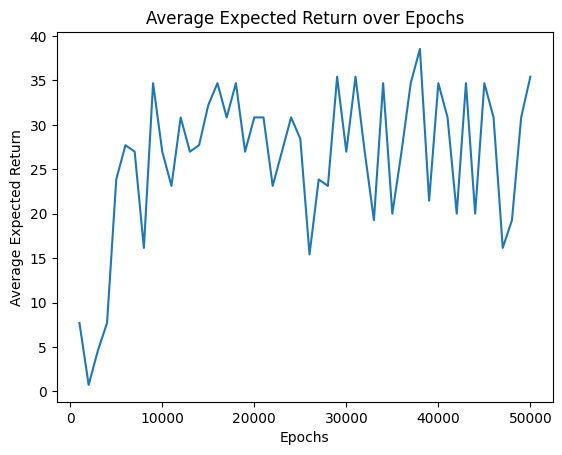

In [17]:
plt.plot(return_data["Epochs"], return_data["Return"])
plt.xlabel("Epochs")
plt.ylabel("Average Expected Return")
plt.title("Average Expected Return over Epochs")

# 2.2 Average Expected Return with 100000 Epochs

In [ ]:
env = gym.make("CatAndMouse-5050_entry")

return_values=[]

for j in range(10):
    q_mouse, q_cat = independent_q_learning(env, epochs = 100000, epsilon = 0.1, gamma = 0.9, alpha = 0.01)

    terminated = False
    truncated = False
    
    observation, _ = env.reset()

    return_value = 0
    t=1
    while(not terminated and not truncated):
        cat_state_num = get_cat_state_num(observation)
        mouse_state_num = get_mouse_state_num(observation)
        
        cat_action = np.argmax(q_cat[cat_state_num])
        mouse_action = np.argmax(q_mouse[mouse_state_num])
        
        joint_action = (mouse_action, cat_action)
        
        observation, reward, terminated, truncated, _ = env.step(joint_action)

        return_value += reward*(0.9**t)
        t+=1
    
    return_values.append(return_value)

print(return_values)

return_values = pd.DataFrame(return_values)
return_values.to_csv("return_values_100000_epochs.csv")

c:\Users\woong\AppData\Local\Programs\Python\Python312\Lib\site-packages\gymnasium\utils\passive_env_checker.py:131: UserWarning: WARN: The obs returned by the `reset()` method was expecting a numpy array, actual type: <class 'tuple'>
  logger.warn(
c:\Users\woong\AppData\Local\Programs\Python\Python312\Lib\site-packages\gymnasium\spaces\box.py:240: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")
c:\Users\woong\AppData\Local\Programs\Python\Python312\Lib\site-packages\gymnasium\utils\passive_env_checker.py:131: UserWarning: WARN: The obs returned by the `step()` method was expecting a numpy array, actual type: <class 'tuple'>
  logger.warn(


[38.549915869355715, 38.549915869355715, 38.549915869355715, 38.549915869355715, 38.549915869355715, 38.549915869355715, 38.549915869355715, 38.549915869355715, 0.0, 0.0]


In [10]:
print(np.mean([38.549915869355715, 38.549915869355715, 38.549915869355715, 38.549915869355715, 38.549915869355715, 38.549915869355715, 38.549915869355715, 38.549915869355715, 0.0, 0.0]))

30.83993269548457


In [9]:
print(np.mean(return_values))

NameError: name 'return_values' is not defined

## 2.3 How did learning rate affect the performance?

Let's test by comparing performance with the same model but higher learning rate ($0.01\to 0.9$)

In [ ]:
env = gym.make("CatAndMouse-5050_entry")

return_values=[]

for j in range(10):
    q_mouse, q_cat = independent_q_learning(env, epochs = 100000, epsilon = 0.1, gamma = 0.9, alpha = 0.9)

    terminated = False
    truncated = False
    
    observation, _ = env.reset()

    return_value = 0
    t=1
    while(not terminated and not truncated):
        cat_state_num = get_cat_state_num(observation)
        mouse_state_num = get_mouse_state_num(observation)
        
        cat_action = np.argmax(q_cat[cat_state_num])
        mouse_action = np.argmax(q_mouse[mouse_state_num])
        
        joint_action = (mouse_action, cat_action)
        
        observation, reward, terminated, truncated, _ = env.step(joint_action)

        return_value += reward*(0.9**t)
        t+=1
    
    return_values.append(return_value)

print(return_values)

print(np.mean(return_values))

return_values = pd.DataFrame(return_values)
return_values.to_csv("return_values_100000_epochs.csv")